最適化の手法，重みの初期化を改良して，MNISTの手書き数字の分類を高精度にしてください．

まず，下記のように活性化関数がsigmoid関数の2層のニューラルネットワークを標準偏差が0.01のガウス分布で初期化し，SGDで最適化する例を示します．

In [1]:
import numpy as np

class Relu:
    def __init__(self):
        self.mask = None

    def forward(self, x):
        self.mask = (x <= 0)
        out = x.copy()
        out[self.mask] = 0

        return out

    def backward(self, dout):
        dout[self.mask] = 0
        dx = dout

        return dx

In [2]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

class Sigmoid:
    def __init__(self):
        self.out = None

    def forward(self, x):
        out = sigmoid(x)
        self.out = out
        return out

    def backward(self, dout):
        dx = dout * (1.0 - self.out) * self.out

        return dx

In [3]:
class Affine:
    def __init__(self, W, b):
        self.W =W
        self.b = b
        self.x = None
        self.dW = None
        self.db = None

    def forward(self, x):
        self.x = x
        out = np.dot(self.x, self.W) + self.b

        return out

    def backward(self, dout):
        dx = np.dot(dout, self.W.T)
        self.dW = np.dot(self.x.T, dout)
        self.db = np.sum(dout, axis=0)

        return dx

In [4]:
def softmax(x):
    if x.ndim == 2:
        x = x.T
        x = x - np.max(x, axis=0)
        y = np.exp(x) / np.sum(np.exp(x), axis=0)
        return y.T

    x = x - np.max(x) # オーバーフロー対策
    return np.exp(x) / np.sum(np.exp(x))

In [5]:
def cross_entropy_error(y, t):
    if y.ndim == 1:
        t = t.reshape(1, t.size)
        y = y.reshape(1, y.size)

    batch_size = y.shape[0]
    return -np.sum(t * np.log(y + 1e-7)) / batch_size

In [6]:
class SoftmaxWithLoss:
    def __init__(self):
        self.loss = None
        self.y = None # softmaxの出力
        self.t = None # 教師データ

    def forward(self, x, t):
        self.t = t
        self.y = softmax(x)
        self.loss = cross_entropy_error(self.y, self.t)

        return self.loss

    def backward(self, dout=1):
        batch_size = self.t.shape[0]
        dx = (self.y - self.t) / batch_size #データ1個あたりの誤差にする

        return dx

In [7]:
from collections import OrderedDict

class TwoLayerNet:

    def __init__(self, input_size, hidden_size, output_size, weight_init_std = 0.01):
        # 重みの初期化
        # ★初期値を改良してみてください
        self.params = {}
        self.params['W1'] = weight_init_std * np.random.randn(input_size, hidden_size)
        self.params['b1'] = np.zeros(hidden_size)
        self.params['W2'] = weight_init_std * np.random.randn(hidden_size, output_size)
        self.params['b2'] = np.zeros(output_size)

        # レイヤの生成
        self.layers = OrderedDict()
        self.layers['Affine1'] = Affine(self.params['W1'], self.params['b1'])
        self.layers['Relu1'] = Relu()
        self.layers['Affine2'] = Affine(self.params['W2'], self.params['b2'])

        self.lastLayer = SoftmaxWithLoss()

    def predict(self, x):
        for layer in self.layers.values():
            x = layer.forward(x)

        return x

    # x:入力データ, t:教師データ
    def loss(self, x, t):
        y = self.predict(x)
        return self.lastLayer.forward(y, t)

    def accuracy(self, x, t):
        y = self.predict(x)
        y = np.argmax(y, axis=1)
        if t.ndim != 1 : t = np.argmax(t, axis=1)

        accuracy = np.sum(y == t) / float(x.shape[0])
        return accuracy

    def gradient(self, x, t):
        # forward
        self.loss(x, t)

        # backward
        dout = 1
        dout = self.lastLayer.backward(dout)

        layers = list(self.layers.values())
        layers.reverse()
        for layer in layers:
            dout = layer.backward(dout)

        # 設定
        grads = {}
        grads['W1'], grads['b1'] = self.layers['Affine1'].dW, self.layers['Affine1'].db
        grads['W2'], grads['b2'] = self.layers['Affine2'].dW, self.layers['Affine2'].db

        return grads

以前MNISTデータを保存したディレクトリを指定します

In [8]:
from google.colab import drive
import sys

drive.mount('/content/drive')
save_dir = '/content/drive/MyDrive/data'

Mounted at /content/drive


In [9]:
def load_mnist(save_dir, one_hot_label=True):
  import numpy as np
  from sklearn.model_selection import train_test_split
  import pickle
  import os

  with open(os.path.join(save_dir, 'mnist_X.pkl'), 'rb') as f:
    X = pickle.load(f)
  with open(os.path.join(save_dir, 'mnist_y.pkl'), 'rb') as f:
    y = pickle.load(f)

  x_train, x_test, t_train, t_test = train_test_split(X, y, test_size=10000, random_state=42)

  if one_hot_label:
    t_train = np.eye(10)[t_train]
    t_test = np.eye(10)[t_test]

  return (x_train, t_train), (x_test, t_test)

In [10]:
import tensorflow as tf

# Load MNIST dataset
(x_train_keras, t_train_keras), (x_test_keras, t_test_keras) = tf.keras.datasets.mnist.load_data()

# Normalize the images to a 0-1 range and reshape to (num_samples, 784)
x_train_keras = x_train_keras.reshape(x_train_keras.shape[0], -1) / 255.0
x_test_keras = x_test_keras.reshape(x_test_keras.shape[0], -1) / 255.0

# Convert labels to one-hot encoding
t_train_keras = np.eye(10)[t_train_keras]
t_test_keras = np.eye(10)[t_test_keras]

# Assign to the variables expected by the existing code
x_train, t_train = x_train_keras, t_train_keras
x_test, t_test = x_test_keras, t_test_keras

print(f"x_train shape: {x_train.shape}")
print(f"t_train shape: {t_train.shape}")
print(f"x_test shape: {x_test.shape}")
print(f"t_test shape: {t_test.shape}")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
x_train shape: (60000, 784)
t_train shape: (60000, 10)
x_test shape: (10000, 784)
t_test shape: (10000, 10)


In [11]:
class SGD:

    """確率的勾配降下法（Stochastic Gradient Descent）"""

    def __init__(self, lr=0.01):
        self.lr = lr

    def update(self, params, grads):
        for key in params.keys():
            params[key] -= self.lr * grads[key]

In [18]:
network = TwoLayerNet(input_size=784, hidden_size=50, output_size=10)
# ★Optimizerを変更してみてください
optimizer = SGD()

iters_num = 10000
train_size = x_train.shape[0]
batch_size = 100
learning_rate = 0.1

train_loss_list = []
train_acc_list = []
test_acc_list = []

iter_per_epoch = max(train_size / batch_size, 1)

for i in range(iters_num):
    batch_mask = np.random.choice(train_size, batch_size)
    x_batch = x_train[batch_mask]
    t_batch = t_train[batch_mask]

    # 勾配
    grad = network.gradient(x_batch, t_batch)

    # 更新
    optimizer.update(network.params, grad)

    loss = network.loss(x_batch, t_batch)
    train_loss_list.append(loss)
    # print(loss)

    if i % iter_per_epoch == 0:
        train_acc = network.accuracy(x_train, t_train)
        test_acc = network.accuracy(x_test, t_test)
        train_acc_list.append(train_acc)
        test_acc_list.append(test_acc)
        print(train_acc, test_acc)

0.10595 0.1019
0.5604166666666667 0.5651
0.7954166666666667 0.7999
0.8467666666666667 0.8522
0.8719333333333333 0.8746
0.8843166666666666 0.8888
0.892 0.8945
0.8966166666666666 0.9001
0.9007833333333334 0.9029
0.9039166666666667 0.9068
0.9065 0.9094
0.90935 0.9127
0.9114333333333333 0.9138
0.9138666666666667 0.9168
0.916 0.918
0.9180833333333334 0.9206
0.9196 0.9223


In [20]:
# ★初期値を改良してみてください (He初期化の考え方を取り入れ、ReLU層に対して適切なstdを設定した)
# 今回は隠れ層にReluが使われているため、Heの初期値(sqrt(2/n_in))を参考に、weight_init_stdを調整した。
# input_size=784なので、W1に対してはsqrt(2/784) = 約0.05とした。

network_improved = TwoLayerNet(input_size=784, hidden_size=50, output_size=10, weight_init_std=np.sqrt(2/784))

# ★Optimizerを変更してみてください
optimizer_improved = SGD(lr=0.1)

iters_num_improved = 10000
train_size_improved = x_train.shape[0]
batch_size_improved = 100

improved_train_loss_list = []
improved_train_acc_list = []
improved_test_acc_list = []

iter_per_epoch_improved = max(train_size_improved / batch_size_improved, 1)

for i in range(iters_num_improved):
    batch_mask_improved = np.random.choice(train_size_improved, batch_size_improved)
    x_batch_improved = x_train[batch_mask_improved]
    t_batch_improved = t_train[batch_mask_improved]

    # 勾配
    grad_improved = network_improved.gradient(x_batch_improved, t_batch_improved)

    # 更新
    optimizer_improved.update(network_improved.params, grad_improved)

    loss_improved = network_improved.loss(x_batch_improved, t_batch_improved)
    improved_train_loss_list.append(loss_improved)

    if i % iter_per_epoch_improved == 0:
        train_acc_improved = network_improved.accuracy(x_train, t_train)
        test_acc_improved = network_improved.accuracy(x_test, t_test)
        improved_train_acc_list.append(train_acc_improved)
        improved_test_acc_list.append(test_acc_improved)
        print(train_acc_improved, test_acc_improved)


0.11988333333333333 0.1171
0.9092 0.9151
0.9279333333333334 0.9297
0.9408333333333333 0.9387
0.9480166666666666 0.9477
0.9544 0.9514
0.9591333333333333 0.9563
0.9637 0.9597
0.96555 0.9601
0.9683166666666667 0.9625
0.9710833333333333 0.9646
0.9722333333333333 0.9658
0.9750666666666666 0.9668
0.97525 0.9661
0.978 0.9682
0.9792833333333333 0.9686
0.97945 0.97


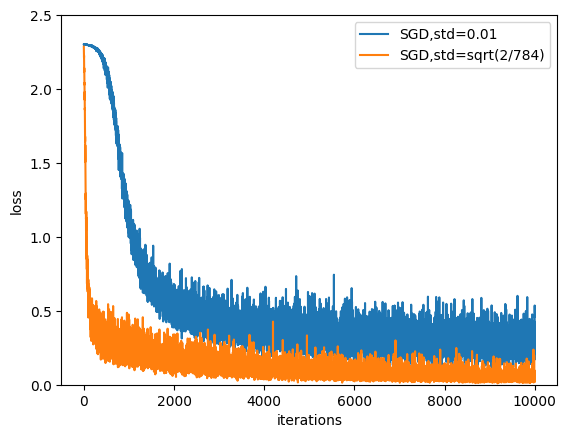

In [21]:
import matplotlib.pyplot as plt
iters_num = 10000 # Define iters_num to avoid NameError
x = np.arange(iters_num)
plt.plot(x, train_loss_list, label='SGD,std=0.01')
plt.plot(x, improved_train_loss_list, label='SGD,std=sqrt(2/784)')
plt.xlabel("iterations")
plt.ylabel("loss")
plt.ylim(0, 2.5)
plt.legend()
plt.show()

以上で初期値を0.01の標準偏差のガウス分布として，SGDで最適化した場合の学習が終わり，学習過程での損失関数の変化をグラフに示すことができました．なお，複数の学習時の損失関数の変化を比較する場合，下記のようにするとグラフを比較できます．損失関数が速く下がると，速く学習ができるといえます．また，最終的な損失関数の値が小さくなると，精度良く学習できていると期待できます．

今回の課題では，最適化手法と重みの初期値を変化させて，できるだけ速く，精度良く，MNISTのデータを学習できるようにトライしてください．
その他のハイパーパラメータ(層の数やノードの数，バッチサイズや学習係数なども) も修正いただいても構いません．

最終的に学習時の損失関数のグラフと，精度の計算結果を含めたNotebookを提出してください．


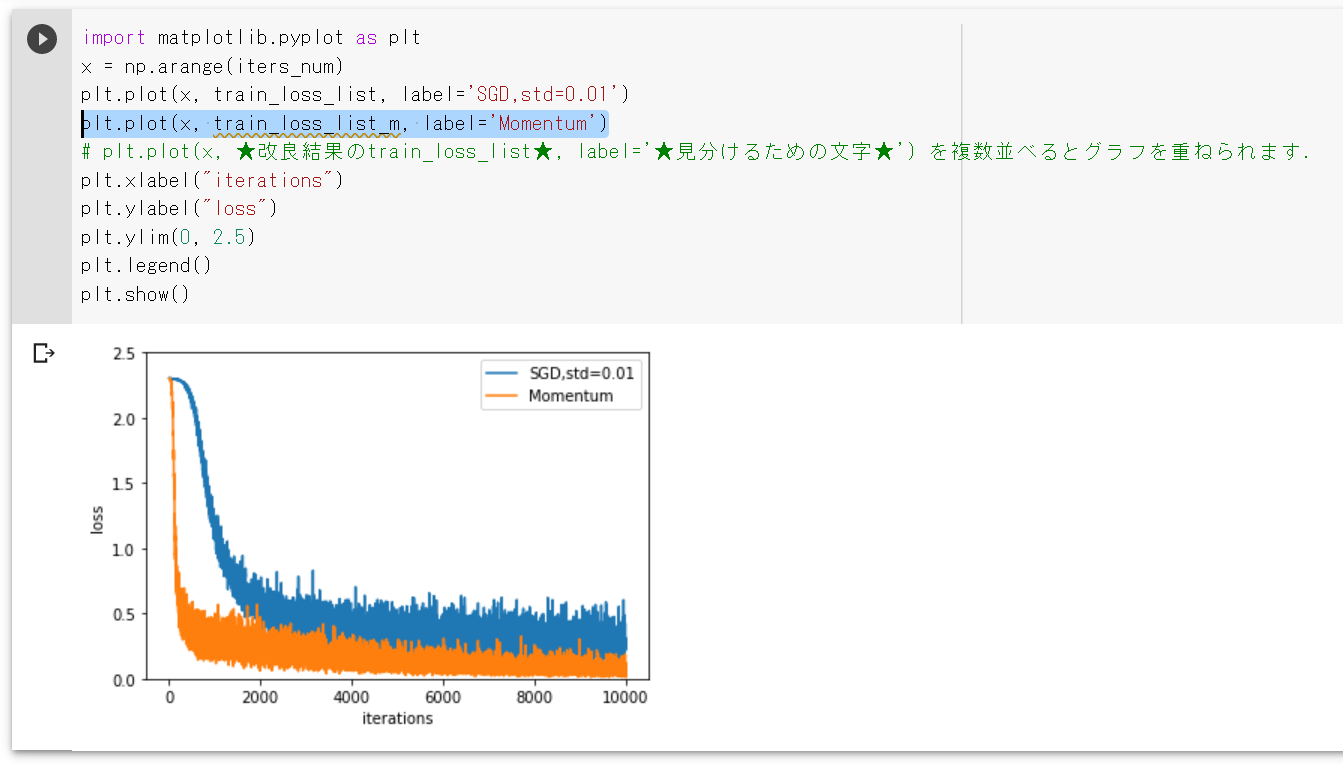

In [24]:
network.accuracy(x_test, t_test)


np.float64(0.9248)

In [25]:
network_improved.accuracy(x_test, t_test)

np.float64(0.9695)